## duhhh

* Spare models (TF-IDF, BoW)
* Dense models (Neural Networks)
    * RNNs (sequence memory)
* embeddings (GloVe) and their nature to Word2Vec
* Geometry Analysis as 2D projections

## 1. Initial Data Visualization

In [24]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../assets/IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [8]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [10]:
df.review[49995]

"I thought this movie did a down right good job. It wasn't as creative or original as the first, but who was expecting it to be. It was a whole lotta fun. the more i think about it the more i like it, and when it comes out on DVD I'm going to pay the money for it very proudly, every last cent. Sharon Stone is great, she always is, even if her movie is horrible(Catwoman), but this movie isn't, this is one of those movies that will be underrated for its lifetime, and it will probably become a classic in like 20 yrs. Don't wait for it to be a classic, watch it now and enjoy it. Don't expect a masterpiece, or something thats gripping and soul touching, just allow yourself to get out of your life and get yourself involved in theirs.<br /><br />All in all, this movie is entertaining and i recommend people who haven't seen it see it, because what the critics and box office say doesn't always count, see it for yourself, you never know, you might just enjoy it. I tip my hat to this movie<br /><

## 2. Data Preparation

In [5]:
# freeze raw text
df['review_raw'] = df['review']

In [6]:
import string
import nltk

from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.tokenize import word_tokenize

In [7]:
# preprocessing function that is safe for all pipelines

def clean_text(text):
    text = text.lower()
    text = text.replace('<br />', '')
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['review_clean'] = df['review_raw'].apply(clean_text)

In [191]:
df['review_clean'][49995]

'i thought this movie did a down right good job it wasnt as creative or original as the first but who was expecting it to be it was a whole lotta fun the more i think about it the more i like it and when it comes out on dvd im going to pay the money for it very proudly every last cent sharon stone is great she always is even if her movie is horriblecatwoman but this movie isnt this is one of those movies that will be underrated for its lifetime and it will probably become a classic in like 20 yrs dont wait for it to be a classic watch it now and enjoy it dont expect a masterpiece or something thats gripping and soul touching just allow yourself to get out of your life and get yourself involved in theirsall in all this movie is entertaining and i recommend people who havent seen it see it because what the critics and box office say doesnt always count see it for yourself you never know you might just enjoy it i tip my hat to this movie810'

In [12]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\josep\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\josep\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\josep\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\josep\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [8]:
# function to map part-of-speech (POS) tags i.e. preventing 'have':'ha'

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [15]:
# since embeddings prefer lemmatized forms, we standardize on that rather than stemming

lemmatizer = WordNetLemmatizer()

def lemmatize_with_pos(text):
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)

    lemmas = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
    ]
    return lemmas

df['review_lemma'] = df['review_clean'].apply(lemmatize_with_pos)

In [21]:
df['review_lemma'].head()

0    [one, of, the, other, reviewer, have, mention,...
1    [a, wonderful, little, production, the, filmin...
2    [i, think, this, be, a, wonderful, way, to, sp...
3    [basically, theres, a, family, where, a, littl...
4    [petter, matteis, love, in, the, time, of, mon...
Name: review_lemma, dtype: object

#### 2.1 Optional pruning

In [105]:
# removing stopwords

from nltk.corpus import stopwords
stop = set(stopwords.words('english'))

df['review_nb_tokens'] = df['review_lemma'].apply(
    lambda tokens: [t for t in tokens if t not in stop]
)

In [106]:
df['review_nb_tokens'].head()

0    [one, reviewer, mention, watch, 1, oz, episode...
1    [wonderful, little, production, filming, techn...
2    [think, wonderful, way, spend, time, hot, summ...
3    [basically, theres, family, little, boy, jake,...
4    [petter, matteis, love, time, money, visually,...
Name: review_nb_tokens, dtype: object

In [109]:
# removing most frequent words

from collections import Counter

review_list = df['review_nb_tokens'].tolist()
word_list = [item for sublist in review_list for item in sublist]
print(f"number of total words: {len(word_list)}")

word_counter = Counter(word_list)
most_common_words = word_counter.most_common()[:10]
most_common_words = pd.DataFrame(most_common_words)
most_common_words.columns = ['word', 'freq']
most_common_words

number of total words: 5978024


,word,freq
0,movie,98940
1,film,91384
2,one,52648
3,make,43342
4,like,42781
5,see,40554
6,good,35658
7,get,35293
8,time,29473
9,character,27567


In [110]:
# remove = most_common_words.word.tolist()[:2]

REMOVE_THRESHOLD = 90000
remove = most_common_words[
    most_common_words['freq'] > REMOVE_THRESHOLD
]['word'].tolist()

df['review_nb_tokens'] = df['review_nb_tokens'].apply(
    lambda tokens: [t for t in tokens if t not in remove]
)

#### 2.3 Diverge pipelines

In [113]:
df['review_nb_text'] = df['review_nb_tokens'].apply(lambda x: " ".join(x))

In [16]:
df['review_embed_text'] = df['review_lemma'].apply(lambda x: " ".join(x))

## 3. Baseline Architectures: Sparse

In [64]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc, 
                             mean_squared_error, log_loss, precision_recall_curve, classification_report, 
                             precision_recall_fscore_support)

In [40]:
# function for basic evaluation

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name=""):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, pred_train)
    test_acc = accuracy_score(y_test, pred_test)
    
    print(f"{model_name} Results:")
    print(f"Train Accuracy: {train_acc:}")
    print(f"Test Accuracy: {test_acc:}")
    print(f"Test Classification Report:\n{classification_report(y_test, pred_test)}")
    
    return pred_test, test_acc

In [42]:
# function for getting top predictive features for each class

def get_top_features(vectorizer, model, n=20, class_names=None):
    """
    Args:
        vectorizer: Fitted vectorizer (CountVectorizer or TfidfVectorizer)
        model: Trained logistic regression model
        n: Number of top features to show
        class_names: List of class names, e.g., ['negative', 'positive']
    """
    if class_names is None:
        class_names = ['class_0', 'class_1']
    
    feature_names = vectorizer.get_feature_names_out()
    
    if hasattr(model, 'coef_'):
        # check if binary classification with one coefficient set
        if model.coef_.shape[0] == 1:
            coef = model.coef_[0]
            
            # features that predict class 1 (positive coefficients)
            pos_indices = np.argsort(coef)[-n:]
            print(f"\nTop {n} features predicting {class_names[1]}:")
            for idx in reversed(pos_indices):
                print(f"  {feature_names[idx]}: {coef[idx]:.4f}")
            
            # features that predict class 0 (negative coefficients)
            neg_indices = np.argsort(coef)[:n]
            print(f"\nTop {n} features predicting {class_names[0]}:")
            for idx in neg_indices:
                print(f"  {feature_names[idx]}: {coef[idx]:.4f}")

In [123]:
# if optional pruning is performed

X = df['review_nb_text']
y = df['sentiment'].map({'negative': 0, 'positive': 1})

In [124]:
# if optional pruning is not performed

X = df['review_lemma'].apply(lambda x: " ".join(x))
y = df['sentiment'].map({'negative': 0, 'positive': 1})

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.3, random_state=1000
)

In [84]:
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (35000,) | X_test shape: (15000,)


#### 3.1 Naive Bayes on Bag of Words

In [51]:
# Bag of Words using CountVectorizer

bow = CountVectorizer(
    max_features=25000, 
    lowercase=True, 
    analyzer="word"
)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [52]:
# initialize a Random Forest classifier with 100 trees
NB = MultinomialNB() 

NB.fit(X_train_bow, y_train)

MultinomialNB()

In [55]:
nb_bow_test = evaluate_model(NB, X_train_bow, X_test_bow, y_train, y_test, "Naive Bayes on BoW")

Naive Bayes on BoW Results:
Train Accuracy: 0.8817428571428572
Test Accuracy: 0.8516666666666667
Test Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      7523
           1       0.87      0.83      0.85      7477

    accuracy                           0.85     15000
   macro avg       0.85      0.85      0.85     15000
weighted avg       0.85      0.85      0.85     15000



#### 3.2 Naive Bayes on TF-IDF

In [128]:
tfidf = TfidfVectorizer(
    max_features=25000,
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 1) # try (2, 1)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [59]:
NB = MultinomialNB()
NB.fit(X_train_tfidf, y_train)

MultinomialNB()

In [62]:
nb_tfidf_test = evaluate_model(NB, X_train_tfidf, X_test_tfidf, y_train, y_test, "Naive Bayes on TF-IDF")

Naive Bayes on TF-IDF Results:
Train Accuracy: 0.8927428571428572
Test Accuracy: 0.8582666666666666
Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      7523
           1       0.87      0.85      0.86      7477

    accuracy                           0.86     15000
   macro avg       0.86      0.86      0.86     15000
weighted avg       0.86      0.86      0.86     15000



#### 3.3 Logistic Regression on TF-IDF

In [127]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

In [67]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    n_jobs=1 # -1 for all cores
)

logreg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, n_jobs=1)

In [68]:
logreg_tfidf_test = evaluate_model(logreg, X_train_tfidf, X_test_tfidf, y_train, y_test, "Logistic Regression on TF-IDF")

Logistic Regression on TF-IDF Results:
Train Accuracy: 0.9266857142857143
Test Accuracy: 0.8893333333333333
Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      7523
           1       0.88      0.91      0.89      7477

    accuracy                           0.89     15000
   macro avg       0.89      0.89      0.89     15000
weighted avg       0.89      0.89      0.89     15000



In [76]:
get_top_features(vectorizer, logreg, n=15)


Top 15 features predicting class_1:
  great: 7.8423
  excellent: 6.5638
  best: 5.5330
  perfect: 5.1392
  love: 4.8751
  favorite: 4.7310
  wonderful: 4.7030
  brilliant: 4.5230
  enjoy: 4.4209
  fun: 4.0249
  710: 3.9303
  hilarious: 3.8337
  superb: 3.7413
  today: 3.5603
  amazing: 3.5534

Top 15 features predicting class_0:
  bad: -11.6269
  waste: -8.1540
  awful: -7.5386
  terrible: -5.7666
  boring: -5.7502
  poor: -5.7115
  fail: -5.3003
  dull: -4.7397
  horrible: -4.7143
  suppose: -4.6551
  poorly: -4.5866
  lame: -4.4450
  unfortunately: -4.2414
  lack: -4.1948
  bore: -4.1919


#### 3.4 TF-IDF + Dense network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D

from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

In [ ]:
def create_dense_model(input_dim, hidden_dim=128):
    model = Sequential([
        Input(shape=(input_dim,)),
        
        # Layer 1: Feature Extraction
        # Takes 'input_dim' number of TF-IDF scores, learns 128 patterns
        Dense(hidden_dim, activation='relu', input_shape=(input_dim,)),
        
        Dropout(0.5),  # randomly turns off 50% of neurons during training
        
        # Layer 2: Pattern Refinement  
        # Takes 128 patterns, learns 64 higher-level patterns
        Dense(hidden_dim // 2, activation='relu'),
        
        Dropout(0.3),  # randomly turns off 30% of neurons
        
        # Output Layer: Decision-Making
        # Takes 64 patterns, outputs single sentiment score
        Dense(1, activation='sigmoid')  # 0=negative, 1=positive
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [86]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # accuracy plot
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # loss plot
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

In [89]:
# convert sparse matrices to dense matrices
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

# get input dimension (vocabulary size)
input_dim = X_train_dense.shape[1]
print(f"Input dimension (vocabulary size): {input_dim}")

# create and train model
model = create_dense_model(input_dim, hidden_dim=128)

# early stopping to prevent overfitting 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# train the model
history_tfidf = model.fit(
    X_train_dense, y_train,
    validation_data=(X_test_dense, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Input dimension (vocabulary size): 20000


C:\Users\josep\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.8083 - loss: 0.4158 - val_accuracy: 0.8934 - val_loss: 0.2624
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.9449 - loss: 0.1496 - val_accuracy: 0.8887 - val_loss: 0.2871
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9725 - loss: 0.0818 - val_accuracy: 0.8831 - val_loss: 0.3635
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9864 - loss: 0.0423 - val_accuracy: 0.8821 - val_loss: 0.4476


In [234]:
# function to extract feature importance from the first dense layer

def get_nn_feature_importance(model, vectorizer, n=20):
    weights = model.layers[0].get_weights()[0]  # shape: (input_dim, hidden_dim)

    importance_scores = np.mean(np.abs(weights), axis=1)
    
    feature_names = vectorizer.get_feature_names_out()
    
    top_indices = np.argsort(importance_scores)[-n:]
    
    print("\nTop features by approximate importance (NN):")
    for idx in reversed(top_indices):
        print(f"{feature_names[idx]}: {importance_scores[idx]:.4f}")
    
    return importance_scores

get_nn_feature_importance(model, vectorizer)


Top features by approximate importance (NN):
awful: 0.1478
bad: 0.1445
810: 0.1393
waste: 0.1341
710: 0.1297
410: 0.1175
excellent: 0.1154
poor: 0.1132
boring: 0.1129
fail: 0.1129
disappointment: 0.1119
terrible: 0.1116
310: 0.1100
dull: 0.1062
waste time: 0.1050
poorly: 0.1016
bad ive: 0.1006
gem: 0.0976
highly recommend: 0.0973
pointless: 0.0971


array([0.02635532, 0.04797198, 0.02603327, ..., 0.03015339, 0.03467853,
       0.02067816], dtype=float32)

In [147]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │       2,560,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,705,349 (29.39 MB)

 Trainable params: 2,568,449 (9.80 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,136,900 (19.60 MB)

In [ ]:
tfidf_dense_acc = history_tfidf.history['val_accuracy'][-1]

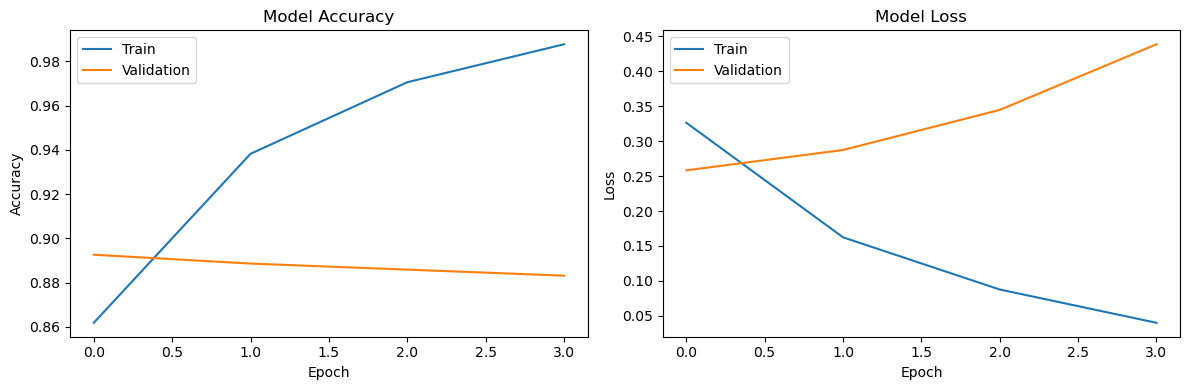

In [231]:
plot_training_history(history_tfidf)

**Notes**
* **Signs of overfitting:** training accuracy and loss improve rapidly while validation loss increases. This indicates the model is fitting dataset-specific correlations (including noise) that do not generalize to unseen data
* **Memory inefficiency:** with an input dimension of 20k, each dense layer introduces ```input_dim x hidden_dim``` parameters, resulting in millions of weights. This high capacity makes the model both computationally expensive and prone to overfitting without very large datasets
* **Representation limitation:** while dense layers with nonlinear activations can learn complex decision boundaries, TF-IDF is a bag-of-words representation that discards word order and context. The model can only learn interactions by combining independent word dimensions (e.g., co-activation of “highly” and “recommend”), rather than modeling phrases or semantics directly
* **Modern architectures** learn dense, lower-dimensional representations that capture semantic relationships. The neurons in our dense layers adapt to the training data, but they are limited by the representation of the input. With better input representations, the neurons can learn more meaningful patterns. Embeddings allow for semantic generalization by representing similar words with similar vectors. Beyond that, our classic models so far are trained from scratch on this specific data set. We have yet to leverage knowledge from other texts or domains

## 4. Geometry Analysis I

* SVD processes ```sparse``` matrices (zero columns)
* SVD explain maximum variances with minimum dimensions
* Dimensionality reduction trades interpretability and separability for visualization

In [130]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

#### 4.1 Naive Bayes

##### Naive Bayes on Bag of Words

In [96]:
# function for 2D visualizations

def plot_svd_components(X_sparse, labels, title, sample_size=500):
    if X_sparse.shape[0] > sample_size:
        indices = np.random.choice(X_sparse.shape[0], sample_size, replace=False)
        X_sample = X_sparse[indices]
        labels_sample = labels[indices]
    else:
        X_sample = X_sparse
        labels_sample = labels
    
    svd = TruncatedSVD(n_components=2, random_state=42)
    X_2d = svd.fit_transform(X_sample)
    
    plt.figure()
    for sentiment in ['positive', 'negative']:
        idx = labels == sentiment
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=sentiment,
            alpha=0.6
        )
        
    plt.title(title)
    plt.legend()
    plt.show()

In [98]:
sample_df = df.sample(500, random_state=42)
labels = sample_df['sentiment']

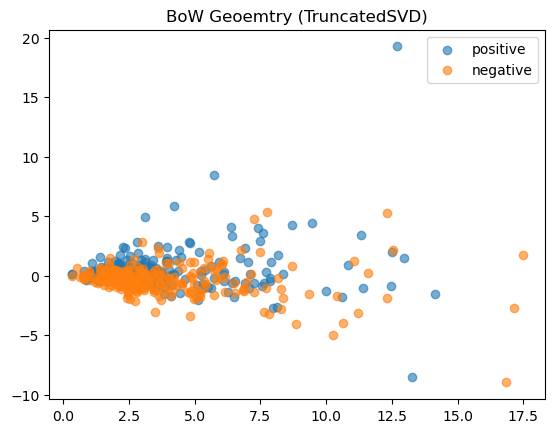

In [101]:
X_bow_sample = bow.transform(sample_df['review_nb_text'])

plot_svd_components(X_bow_sample, labels, "BoW Geoemtry (TruncatedSVD)")

**Notes**
* The axes correspond to the top singular directions (latent factors) that explain the most variance in token statistics, not sentiment
* Many points collapse near (0, 0). SVD finds directions relative to the global mean of data, meaning 'typical' reviews are highly present. This can be improved by surpressing more common words, which is performed within TF-IDF
* The 2D projection struggles with linear separation -- this does not mean the original space is not linearly separable. Loss of separation in 2D is expected because SVD collapses information while preserving variance, not class structure. However, the projection still reveals that sentiment is not a dominant global source of variance, highlighting limitations of BoW representations
* Naive Bayes succeeds despite poor global geometry because it aggregates local token evidence under a conditional independence assumption

##### Naive Bayes on TF-IDF

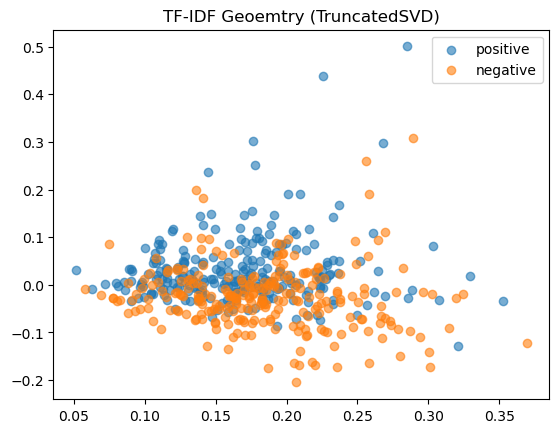

In [105]:
X_tfidf_sample = tfidf.transform(sample_df['review_nb_text'])

plot_svd_components(X_tfidf_sample, labels, "TF-IDF Geoemtry (TruncatedSVD)")

**Notes**
* Tighter clustering reflects TF-IDF reducing dominance of high-frequency tokens via downweighting common words and upweighting sentiment-carrying words
* A weak sentiment gradient emerges (positive reviews trending upward, negative downward), indicating sentiment contributes some variance
* TF-IDF begins to encode semantic polarity, but sentiment remains a low-energy signal relative to topic and style

#### 4.2 Logistic Regression on TF-IDF

* Logistic Regression better trends towards exploting sentiment as a direction in vector space

In [140]:
# project data into 2D to visualize hyperplane

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_train_tfidf)

In [142]:
print("Explained variance (2 comps):", svd.explained_variance_ratio_.sum())

Explained variance (2 comps): 0.004824531290405283


* ~ 0.0048 = 0.48% of the total variance captured by the first two SVD components. The TF-IDF space is very high dimensional and extremely sparse; most variance lives in many directions. A 2D slice is therefore not representative, but we will proceed for the sake of intuition of the decision boundary, although being unreliable

In [144]:
# train Logistic Regression in 2D

clf_2d = LogisticRegression(random_state=42, max_iter=1000)
clf_2d.fit(X_2d, y_train)

LogisticRegression(max_iter=1000, random_state=42)

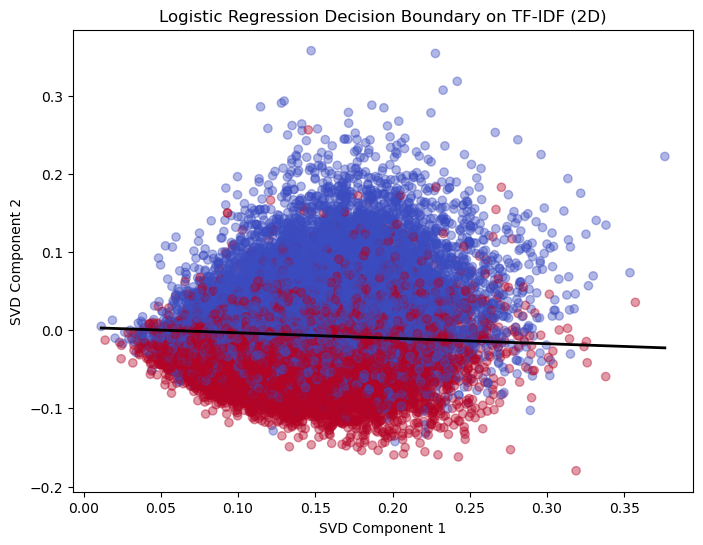

In [159]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.4
)

# decision boundary
xx = np.linspace(X_2d[:,0].min(), X_2d[:,0].max(), 100)
yy = -(clf_2d.coef_[0][0] * xx + clf_2d.intercept_[0]) / clf_2d.coef_[0][1]

plt.plot(xx, yy, color="black", linewidth=2)

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("Logistic Regression Decision Boundary on TF-IDF (2D)")
plt.show()

Explained variance (50 comps): 0.09993186580282731


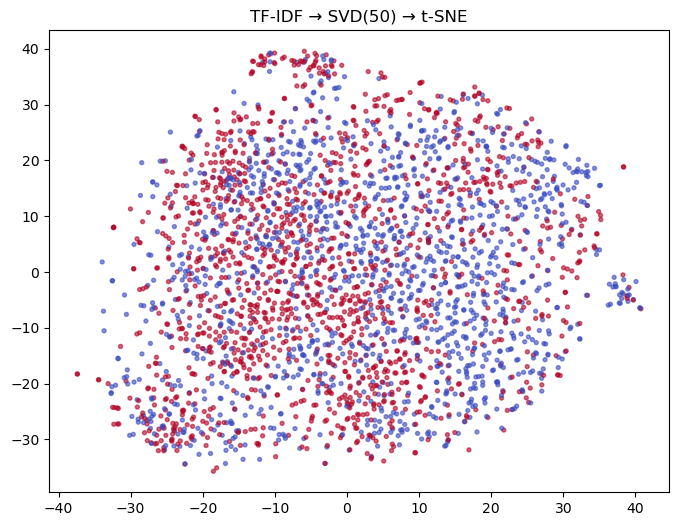

In [132]:
svd50 = TruncatedSVD(n_components=50, random_state=42)
X_50 = svd50.fit_transform(X_train_tfidf)
print("Explained variance (50 comps):", svd50.explained_variance_ratio_.sum())

# t-SNE on subset for speed
subset = np.random.choice(len(X_50), size=min(3000, len(X_50)), replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_50[subset])

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train.iloc[subset], cmap="coolwarm", alpha=0.6, s=8)
plt.title("TF-IDF → SVD(50) → t-SNE")
plt.show()

**Notes**
* Although SVD(50) preserves only ~10% of the total TF-IDF variance, the resulting t-SNE visualization reveals weak local clustering without global class separation, indicating that sentiment information is distributed across many dimensions and is not geometrically separable in low-dimensional space.
* The decision boundary likely exists in very high dimensions, as linear models (Logistic Regression) still perform well with TF-IDF encoding lexical salience, not semantic meaning. t-SNE preserves local neighborhood structure, so the presence of small, scattered clusters suggests that some semantically similar reviews group together, but these groupings are not sentiment-pure

## 5. Embedding Architectures I: Dense

* Dense matrix (non-zero columns)
* Embeddings are inspired by ```Word2Vec``` (library now oudated)
* Convolutions and Pooling to retain previous learning

In [17]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D

from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Concatenate

In [18]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # accuracy plot
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # loss plot
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

In [19]:
X = df['review_embed_text']
y = df['sentiment'].map({'negative': 0, 'positive': 1})

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1000
)

In [21]:
max_vocab = 20000 # similar to TF-IDF vector max features
tokenizer = Tokenizer(
    num_words=max_vocab,
    oov_token="<UNK>"
)
tokenizer.fit_on_texts(X_train)

In [62]:
# run once to find average review length for the sake of stable tensors

sequences = tokenizer.texts_to_sequences(df['review_clean'])
lengths = [len(seq) for seq in sequences]

print("Mean:", int(np.mean(lengths)))
print("Median:", int(np.median(lengths)))
print("90th %:", int(np.percentile(lengths, 90)))
print("95th %:", int(np.percentile(lengths, 95)))
print("Max:", max(lengths))

Mean: 226
Median: 170
90th %: 442
95th %: 578
Max: 2450


In [22]:
max_len = 512   # roughly average review length for the sake of stable tensors

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

#### 5.1 Embedding + Global Average Pooling

In [117]:
embedding_dim = 100  # analogous to Word2Vec vector size

model_with_embedding = Sequential([
    # word -> vector lookup (Word2Vec lives here)
    Embedding(
        input_dim=max_vocab,
        output_dim=embedding_dim,
    ),
    
    # captures average of word vectors i.e. topic / semantics
    GlobalAveragePooling1D(),
    
    # same classifier as before
    Dense(128, activation="relu"),
    Dropout(0.5),
    
    Dense(64, activation="relu"),
    Dropout(0.3),
    
    Dense(1, activation="sigmoid")
])

model_with_embedding.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [119]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_embed = model_with_embedding.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.5357 - loss: 0.6777 - val_accuracy: 0.8480 - val_loss: 0.3600
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.8277 - loss: 0.3845 - val_accuracy: 0.7427 - val_loss: 0.5448
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.8625 - loss: 0.3279 - val_accuracy: 0.8599 - val_loss: 0.3306
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.8887 - loss: 0.2740 - val_accuracy: 0.8927 - val_loss: 0.2784
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.8951 - loss: 0.2615 - val_accuracy: 0.8860 - val_loss: 0.2779
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9108 - loss: 0.2273 - val_accuracy: 0.8937 - val_loss: 0.2723
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9065 - loss: 0.2384 - val_accuracy: 0.8857 - val_loss: 0.2822
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.9279 -

In [125]:
model_with_embedding.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 512, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 100)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,063,749 (23.13 MB)

 Trainable params: 2,021,249 (7.71 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,042,500 (15.42 MB)

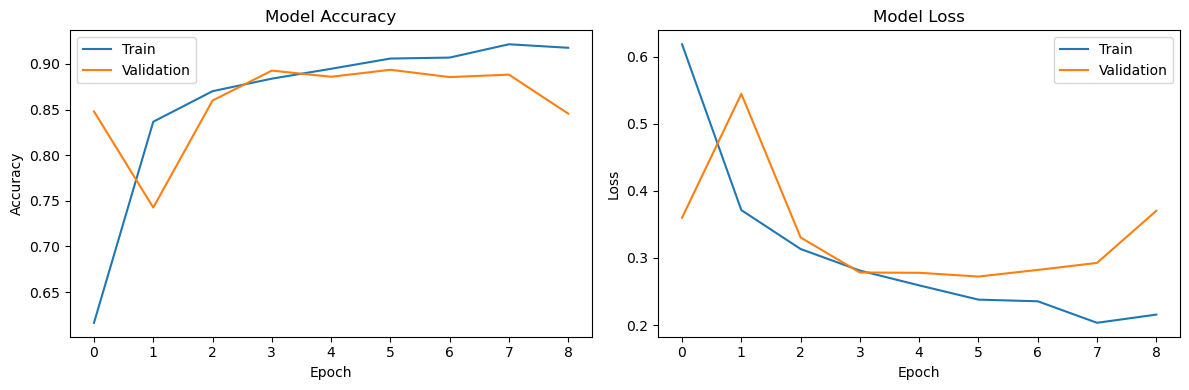

In [127]:
plot_training_history(history_embed)

In [149]:
embedding_pooling_acc = history_embed.history['val_accuracy'][-1]
print(f"Embeddings + Average Pooling Accuracy: {embedding_pooling_acc}")
print(f"TF-IDF + Dense Layer Accuracy: {tfidf_dense_acc}")
print(f"Logistic Regression (TF-IDF) Accuracy: {logreg_tfidf_test[-1]}")
print(f"Naive Bayes (TF-IDF) Accuracy: {nb_tfidf_test[-1]}")

Embeddings + Average Pooling Accuracy: 0.8456000089645386
TF-IDF + Dense Layer Accuracy: 0.8821333050727844
Logistic Regression (TF-IDF) Accuracy: 0.8893333333333333
Naive Bayes (TF-IDF) Accuracy: 0.8582666666666666


**Notes**
* Training and validation accuracy closely track each other, indicating reduced overfitting and more stable generalization
* Embeddings compress lexical variation into dense vectors and significantly reduce input dimensionality, limiting model capacity
* TF-IDF initially outperforms embeddings with average pooling due to its strong inductive bias: explicit term weighting highlights class-specific keywords. However, the embedding model generalizes more smoothly and overfits less, suggesting a stronger representational foundation that can benefit from additional structure

#### 5.2 Embedding + Conv1D + Global Max Pooling

In [111]:
embedding_dim = 100  # analogous to vector size, however more condensed

model_with_conv = Sequential([
    # word -> vector lookup (Word2Vec lives here)
    Embedding(
        input_dim=max_vocab,
        output_dim=embedding_dim,
    ),

    Conv1D(
        filters=128,
        kernel_size=5, # 5 to detect short phrases
        activation="relu",
        padding="valid"
    ),
    
    # captures strong signals i.e. sentiment / triggers
    GlobalMaxPooling1D(),
    
    # same classifier as before
    Dense(128, activation="relu"),
    Dropout(0.5),
    
    Dense(64, activation="relu"),
    Dropout(0.3),
    
    Dense(1, activation="sigmoid")
])

model_with_conv.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [113]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_conv = model_with_conv.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 53s 47ms/step - accuracy: 0.7108 - loss: 0.5164 - val_accuracy: 0.8883 - val_loss: 0.2672
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 48s 44ms/step - accuracy: 0.9347 - loss: 0.1743 - val_accuracy: 0.8940 - val_loss: 0.2840
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 48s 44ms/step - accuracy: 0.9810 - loss: 0.0586 - val_accuracy: 0.8935 - val_loss: 0.3667
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 49s 45ms/step - accuracy: 0.9915 - loss: 0.0263 - val_accuracy: 0.8902 - val_loss: 0.3663


In [120]:
model_with_conv.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 512, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 508, 128)            │          64,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_1               │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,266,885 (23.91 MB)

 Trainable params: 2,088,961 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,177,924 (15.94 MB)

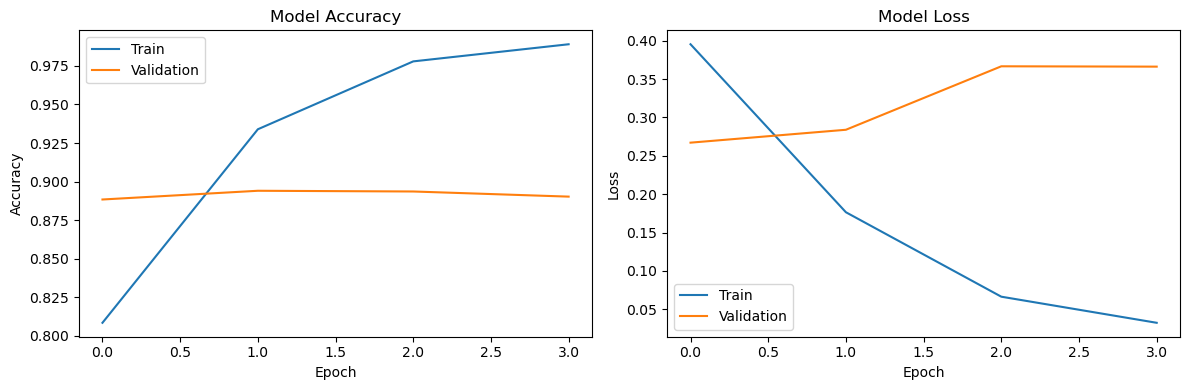

In [121]:
plot_training_history(history_conv)

In [153]:
print(f"Embeddings + Average Pooling Accuracy: {history_embed.history['val_accuracy'][-1]}")
print(f"Embeddings + Conv1D + Max Pooling Accuracy: {history_conv.history['val_accuracy'][-1]}")

Embeddings + Average Pooling Accuracy: 0.8456000089645386
Embeddings + Conv1D + Max Pooling Accuracy: 0.8902000188827515


**Notes**

* Average pooling assumes sentiment is distributed across a document, while max pooling assumes sentiment is driven by a small number of highly salient phrases. For sentiment analysis, max pooling is often effective because rare but strong signals can dominate the classification
* Conv1D learns local n-gram-like patterns by sliding a fixed-width window over the embedding sequence and detecting phrase-level features in vector space. Global max pooling then selects the single strongest activation across the document, effectively making the prediction hinge on the most salient detected phrase
* However, this pooling strategy is too aggressive for nuanced or mixed sentiment. Once a strong activation is found, the rest of the document is ignored. This is reflected in the consistently increasing validation loss and stagnant validation accuracy, indicating memorization of trigger phrases rather than robust generalization

#### 5.3 Embedding + Conv1D + Avg+Max Pooling

In [165]:
inputs = Input(shape=(max_len,))

x = Embedding(
    input_dim=max_vocab,
    output_dim=embedding_dim
)(inputs)

x = Conv1D(
    filters=128,
    kernel_size=3,
    activation="relu"
)(x)

avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)

x = Concatenate()([avg_pool, max_pool])

x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

model_conc = Model(inputs, outputs)

model_conc.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [167]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_conc = model_with_conv.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 48s 44ms/step - accuracy: 0.9392 - loss: 0.1722 - val_accuracy: 0.8976 - val_loss: 0.2588
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 49s 45ms/step - accuracy: 0.9811 - loss: 0.0606 - val_accuracy: 0.8883 - val_loss: 0.3473
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 48s 44ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.8943 - val_loss: 0.4170
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 47s 43ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.8931 - val_loss: 0.4910


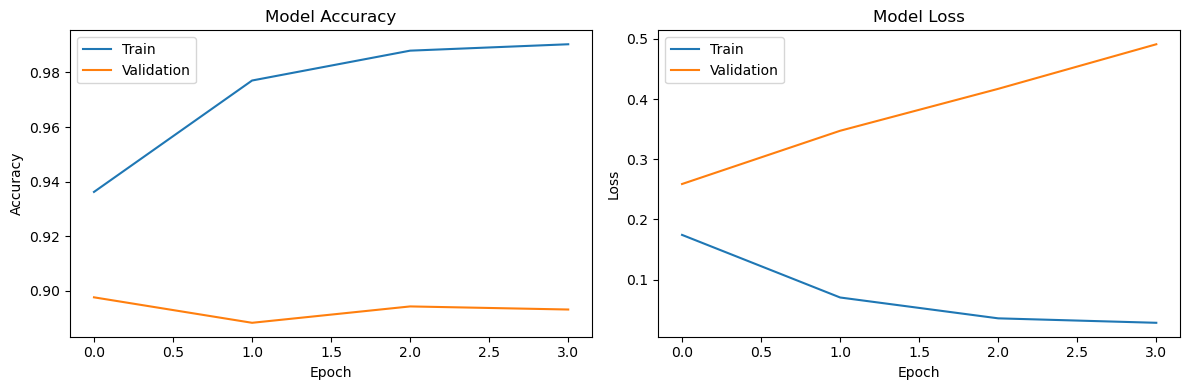

In [173]:
plot_training_history(history_conc)

In [183]:
print(f"Conv1D + Avg+Max Accuracy: {history_conc.history['val_accuracy'][-1]}")

Conv1D + Avg+Max Accuracy: 0.8931333422660828


**Notes**

* Concatenating global average and max pooling allows the network to retain both global semantic information and localized salient phrases. While this increases expressiveness, it also substantially increases the model’s freedom to fit dataset-specific patterns
* This model exhibits the largest train-validation gap, indicating the highest representational capacity among the tested architectures. This gap exists because the model had enough degrees of freedom to fit the training set extremely well without discovering rules that transfer
* High training accuracy combined with worsening validation performance suggests overfitting. Without strong priors (such as pretrained embeddings) or larger datasets, the model lacks sufficient constraints to generalize effectively

As model expressiveness increases, training performance improves monotonically, but generalization becomes increasingly sensitive to inductive bias and data size. Simpler pooling strategies (GlobalAveragePooling) impose beneficial constraints, while more expressive pooling (Avg+Max) requires stronger priors such as pretrained embeddings.

## 6. Embedding Architectures II: Pre-trained

In [25]:
# load GloVe vectors

glove_path = "../assets/glove.6B.100d.txt"

embeddings_index = {}

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs_vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs_vector

In [26]:
# create embedding matrix

embedding_dim = 100
embedding_matrix = np.zeros((max_vocab, embedding_dim))

for word, idx in tokenizer.word_index.items():
    if idx >= max_vocab:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[idx] = embedding_vector

In [51]:
hits = 0
misses = 0

for word, idx in tokenizer.word_index.items():
    if idx >= max_vocab:
        continue
    if word in embeddings_index:
        hits += 1
    else:
        misses += 1

print(f"Embedding coverage: {hits / (hits + misses):.2%}")

Embedding coverage: 93.96%


#### 6.1 GloVe + Average Pooling

In [187]:
model_glove_avg = Sequential([
    Embedding(
        input_dim=max_vocab,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    Conv1D(128, kernel_size=5, activation="relu"),
    GlobalAveragePooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model_glove_avg.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [189]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_avg = model_glove_avg.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.6650 - loss: 0.6038 - val_accuracy: 0.7945 - val_loss: 0.4486
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.8179 - loss: 0.4094 - val_accuracy: 0.8379 - val_loss: 0.3702
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.8345 - loss: 0.3775 - val_accuracy: 0.8502 - val_loss: 0.3463
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.8515 - loss: 0.3466 - val_accuracy: 0.8435 - val_loss: 0.3539
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.8687 - loss: 0.3158 - val_accuracy: 0.8627 - val_loss: 0.3190
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.8775 - loss: 0.2973 - val_accuracy: 0.8653 - val_loss: 0.3141
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8896 - loss: 0.2731 - val_accuracy: 0.8733 - val_loss: 0.2960
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.8951 -

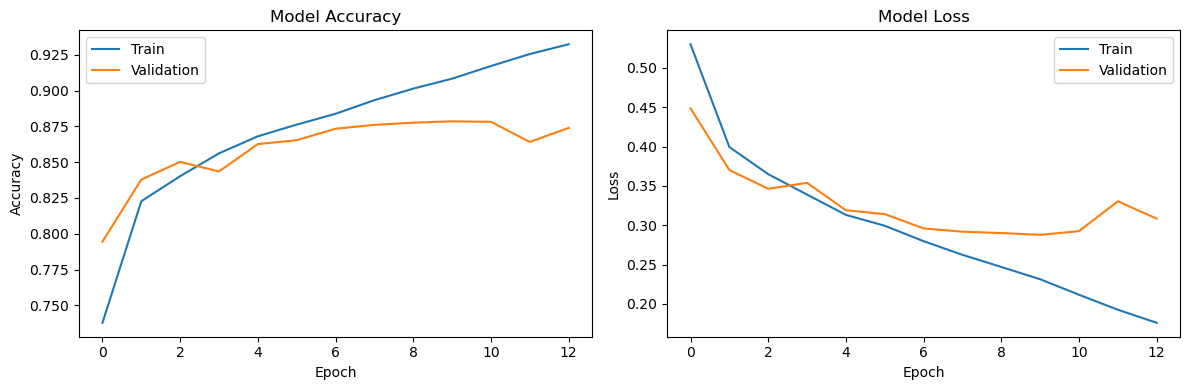

In [192]:
plot_training_history(history_glove_avg)

In [194]:
history_glove_avg.history['val_accuracy'][-1]

0.8739333152770996

Average pooling exhibits the smoothest training and validation curves, with the smallest training–validation gap. This indicates low variance and minimal overfitting, suggesting that average pooling acts as a bias-toward-generalization operator. However, validation accuracy plateaus at a lower level, indicating a limit on expressive power. Average pooling assumes all tokens contribute approximately equally to sentiment--that assumption is wrong in detail, but right on average.

#### 6.2 GloVe (Global Vectors for Word Representation) + Global Max Pooling

In [196]:
model_glove_max = Sequential([
    Embedding(
        input_dim=max_vocab,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    Conv1D(128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model_glove_max.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [198]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_max = model_glove_max.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.6751 - loss: 0.5722 - val_accuracy: 0.8508 - val_loss: 0.3435
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8649 - loss: 0.3229 - val_accuracy: 0.8613 - val_loss: 0.3230
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8911 - loss: 0.2612 - val_accuracy: 0.8656 - val_loss: 0.3211
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9224 - loss: 0.2001 - val_accuracy: 0.8238 - val_loss: 0.4060
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.9440 - loss: 0.1522 - val_accuracy: 0.8614 - val_loss: 0.3995
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9599 - loss: 0.1114 - val_accuracy: 0.8631 - val_loss: 0.4407


In [200]:
model_glove_max.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)             │ (None, 512, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 508, 128)            │          64,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_10              │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,242,309 (8.55 MB)

 Trainable params: 80,769 (315.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

 Optimizer params: 161,540 (631.02 KB)

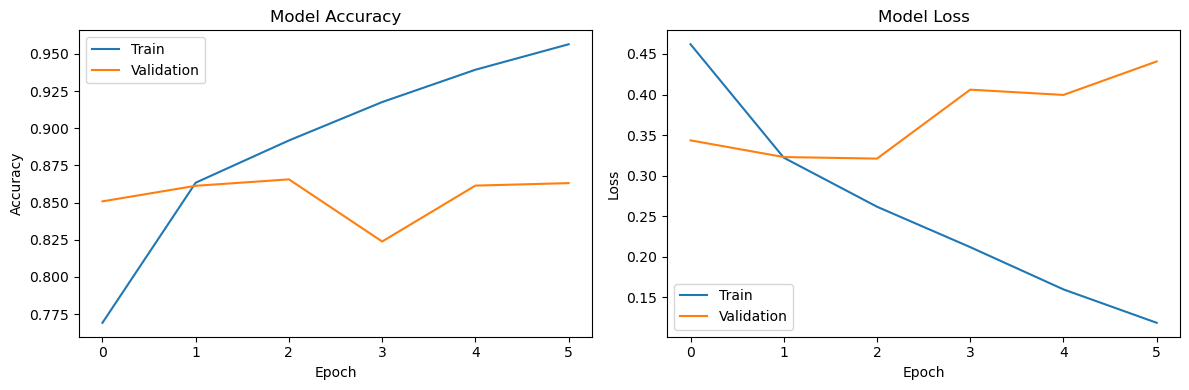

In [202]:
plot_training_history(history_glove_max)

In [204]:
history_glove_max.history['val_accuracy'][-1]

0.8630666732788086

Max pooling leads to faster training accuracy improvements but produces unstable validation accuracy and a larger training–validation gap, indicating higher variance and steeper overfitting. Compared to non-GloVe embeddings, where max pooling had less semantic leverage and training curves appeared nearly linear, this behavior highlights sensitivity to embedding quality. Max pooling effectively selects the strongest sentiment cue anywhere in the review, amplifying both meaningful signals and embedding noise

#### 6.3 GloVe + Avg+Max Pooling

In [206]:
inputs = Input(shape=(None,))

x = Embedding(
    input_dim=max_vocab,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)(inputs)

x = Conv1D(128, kernel_size=5, activation="relu")(x)

avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)

x = Concatenate()([avg_pool, max_pool])

x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(1, activation="sigmoid")(x)

model_glove_avgmax = Model(inputs, outputs)

model_glove_avgmax.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [208]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_avgmax = model_glove_avgmax.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.7036 - loss: 0.5424 - val_accuracy: 0.8363 - val_loss: 0.3686
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.8630 - loss: 0.3220 - val_accuracy: 0.8426 - val_loss: 0.3596
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - accuracy: 0.8938 - loss: 0.2596 - val_accuracy: 0.8692 - val_loss: 0.3128
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.9207 - loss: 0.1988 - val_accuracy: 0.8679 - val_loss: 0.3271
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - accuracy: 0.9460 - loss: 0.1461 - val_accuracy: 0.8617 - val_loss: 0.3737
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - accuracy: 0.9625 - loss: 0.1042 - val_accuracy: 0.8447 - val_loss: 0.4767


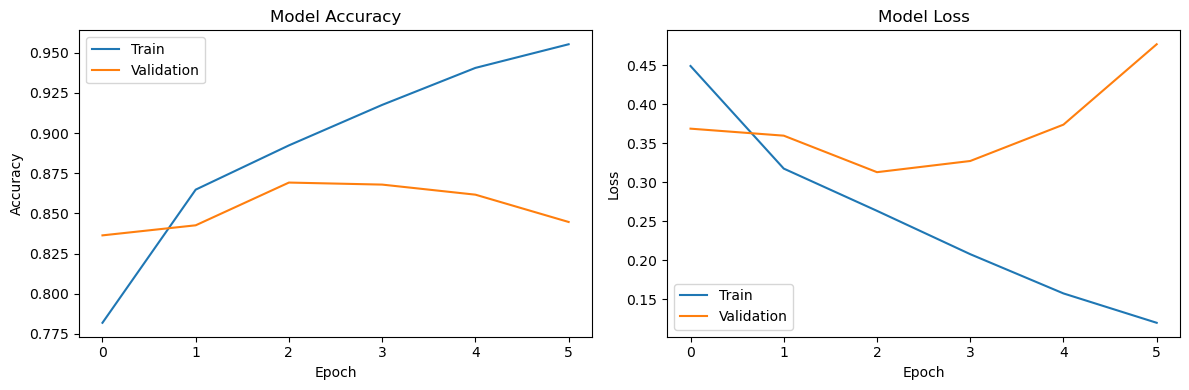

In [210]:
plot_training_history(history_glove_avgmax)

In [185]:
history_glove_avgmax.history['val_accuracy'][-1]

0.8674666881561279

The concatenation of average and max pooling produces behavior that more closely resembles max pooling, but with partial smoothing from the average component. Compared to models without GloVe embeddings, the training dynamics exhibit greater mid-epoch variance, reflecting increased sensitivity to embedding quality. However, the average pooling component stabilizes learning, resulting in smoother curves and less extreme validation degradation than max pooling alone

#### 6.4 Trainable GloVe + Avg+Max Pooling

In [53]:
inputs = Input(shape=(None,))

x = Embedding(
    input_dim=max_vocab,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(inputs)

x = Conv1D(128, kernel_size=5, activation="relu")(x)

avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)

x = Concatenate()([avg_pool, max_pool])

x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(1, activation="sigmoid")(x)

model_glove_avgmax = Model(inputs, outputs)

model_glove_avgmax.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [55]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_avgmax = model_glove_avgmax.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 88s 77ms/step - accuracy: 0.7179 - loss: 0.5209 - val_accuracy: 0.8730 - val_loss: 0.3019
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - accuracy: 0.9090 - loss: 0.2281 - val_accuracy: 0.8909 - val_loss: 0.2622
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 95s 86ms/step - accuracy: 0.9574 - loss: 0.1204 - val_accuracy: 0.8885 - val_loss: 0.2973
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 138s 82ms/step - accuracy: 0.9870 - loss: 0.0445 - val_accuracy: 0.8867 - val_loss: 0.3746
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 92s 84ms/step - accuracy: 0.9920 - loss: 0.0267 - val_accuracy: 0.8861 - val_loss: 0.4491


In [219]:
model_glove_avgmax.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_18 (Embedding)      │ (None, None, 100)         │       2,000,000 │ input_layer_12[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_13 (Conv1D)            │ (None, None, 128)         │          64,128 │ embedding_18[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_13   │ (None, 128)               │               0 │ conv1d_13[0][0]            │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_12       │ (None, 128)               │               0 │ conv1d_13[0][0]            │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_7 (Concatenate)   │ (None, 256)               │               0 │ global_average_pooling1d_… │
│                               │                           │                 │ global_max_pooling1d_12[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_36 (Dense)              │ (None, 128)               │          32,896 │ concatenate_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_18 (Dropout)          │ (None, 128)               │               0 │ dense_36[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_37 (Dense)              │ (None, 1)                 │             129 │ dropout_18[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 6,291,461 (24.00 MB)

 Trainable params: 2,097,153 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,194,308 (16.00 MB)

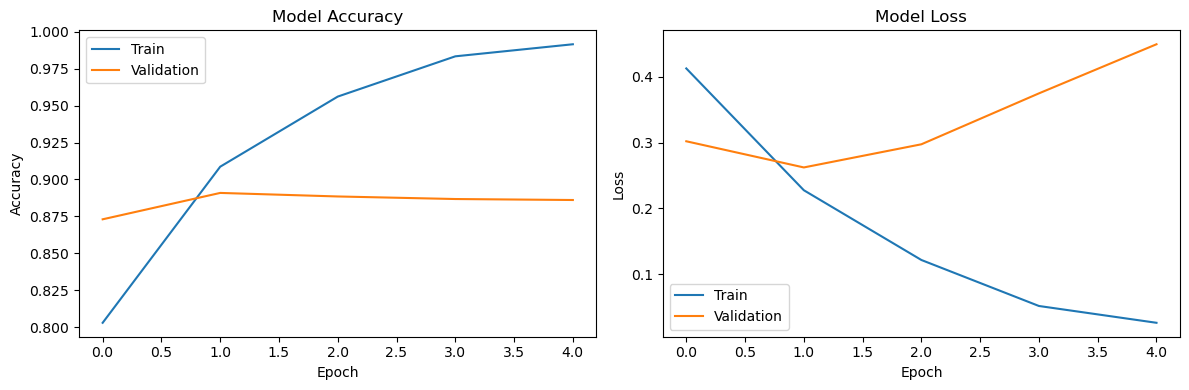

In [58]:
plot_training_history(history_glove_avgmax)

In [61]:
history_glove_avgmax.history['val_accuracy'][-1]

0.8860666751861572

Enabling `trainable=True` results in smoother training curves and more stable validation performance compared to frozen embeddings. The validation accuracy drop-off is reduced, indicating better task alignment of the embedding space. Although this configuration achieves the highest validation accuracy among GloVe-based models, the improvement is marginal, and overall performance remains slightly below the TF-IDF baseline

## 7. Geometry Analysis II

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

#### 7.1 Document Vectors

In [37]:
# document vector: mean of token GloVe vectors
def doc_mean_embedding(text, tokenizer, embedding_matrix, max_vocab, dim):
    seq = tokenizer.texts_to_sequences([text])[0]
    vecs = [
        embedding_matrix[i] 
        for i in seq 
        if i < max_vocab and np.any(embedding_matrix[i])
    ]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

In [45]:
X_train_mean = np.vstack([
    doc_mean_embedding(t, tokenizer, embedding_matrix, max_vocab, embedding_dim) 
    for t in X_train
])

X_test_mean  = np.vstack([
    doc_mean_embedding(t, tokenizer, embedding_matrix, max_vocab, embedding_dim) 
    for t in X_test
])

In [46]:
# document vector: weight of each token vector by its TF-IDF score
def weighted_embedding_from_tfidf_row(row, vocab, tokenizer, embedding_matrix):
    indices = row.indices
    data    = row.data

    vecs = []
    weighted_sum = []

    for col_idx, tfidf_weight in zip(indices, data):
        tfidf_word = vocab[col_idx]                    
        tok_idx = tokenizer.word_index.get(tfidf_word)
        
        if tok_idx and tok_idx < max_vocab and np.any(embedding_matrix[tok_idx]):
            vecs.append(embedding_matrix[tok_idx] * tfidf_weight)
            weighted_sum.append(tfidf_weight)

        if not vecs:
            return np.zeros(embedding_matrix.shape[1])

    return np.sum(vecs, axis=0) / (np.sum(weighted_sum) + 1e-9)

In [58]:
tfidf = TfidfVectorizer(max_features=max_vocab)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

vocab = tfidf.get_feature_names_out()

In [59]:
X_train_weighted = np.vstack([
    weighted_embedding_from_tfidf_row(
        X_train_tfidf[i], 
        vocab, tokenizer, embedding_matrix
    )
    for i in range(X_train_tfidf.shape[0])
])

X_test_weighted = np.vstack([
    weighted_embedding_from_tfidf_row(
        X_test_tfidf[i], 
        vocab, tokenizer, embedding_matrix
    )
    for i in range(X_test_tfidf.shape[0])
])


#### 7.2 Dimensionality Reduction Visualizations

In [60]:
# helper: reduce (PCA/SVD) + t-SNE + plot
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import scipy.sparse as sp

def reduce_and_tsne_plot(X, y, name="Representation", n_components=50,
                         tsne_subset=3000, perplexity=30, random_state=42,
                         scale_for_tsne=True, pca_for_dense=True):
    """
    X: np.ndarray (dense) or scipy.sparse matrix (sparse)
    y: labels (array-like same length as rows of X); used for coloring
    name: plot title prefix
    returns: (X_reduced, X_tsne, subset_idx)
    """
    is_sparse = sp.issparse(X)
    rng = np.random.RandomState(random_state)

    if is_sparse:
        method = "TruncatedSVD"
        reducer = TruncatedSVD(n_components=n_components, random_state=random_state)
        X50 = reducer.fit_transform(X)
        explained = reducer.explained_variance_ratio_.sum()
    else:
        # dense numeric arrays
        if pca_for_dense:
            method = "PCA"
            reducer = PCA(n_components=n_components, random_state=random_state)
            X50 = reducer.fit_transform(X)
            explained = reducer.explained_variance_ratio_.sum()
        else:
            # optionally let user use TruncatedSVD on dense too
            method = "TruncatedSVD"
            reducer = TruncatedSVD(n_components=n_components, random_state=random_state)
            X50 = reducer.fit_transform(X)
            explained = reducer.explained_variance_ratio_.sum()

    print(f"{name}: {method}({n_components}) explained variance (sum) = {explained:.6f}")

    # subset for t-SNE
    n = X50.shape[0]
    subset_size = min(tsne_subset, n)
    subset_idx = rng.choice(n, size=subset_size, replace=False)
    X50_sub = X50[subset_idx]

    if scale_for_tsne:
        X50_sub = StandardScaler().fit_transform(X50_sub)

    tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity)
    X_tsne = tsne.fit_transform(X50_sub)

    plt.figure(figsize=(6,5))
    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=np.array(y)[subset_idx], cmap="coolwarm", s=8, alpha=0.6)
    plt.title(f"{name} -> {method}({n_components}) -> t-SNE (subset {subset_size})")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.show()

    return X50, X_tsne, subset_idx


Explained variance (2 comps): 0.3875417090299236


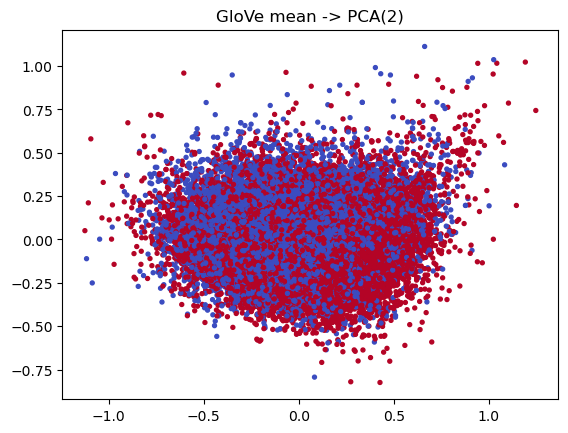

In [142]:
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(X_train_mean)
print("Explained variance (2 comps):", pca2.explained_variance_ratio_.sum())

plt.scatter(X2[:,0], X2[:,1], c=y_train, cmap='coolwarm', s=8)
plt.title("GloVe mean -> PCA(2)")
plt.show()

* Because PCA(2) explains ~38%, 2D still shows quite a lot of the global variance. The dense cloud centered near (0,0) with heavy overlap means the top axes capture document-level variance (length, topic, etc.) but not an axis that cleanly separates sentiment

GloVe mean: PCA(50) explained variance (sum) = 0.912279


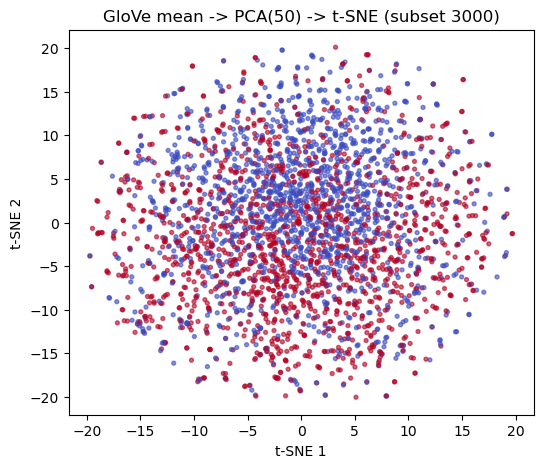

In [209]:
X50p, X_tsne_glove, idx_glove = reduce_and_tsne_plot(
    X_train_mean, y_train,
    name="GloVe mean", n_components=50, tsne_subset=3000
)

TF-IDF: TruncatedSVD(50) explained variance (sum) = 0.099932


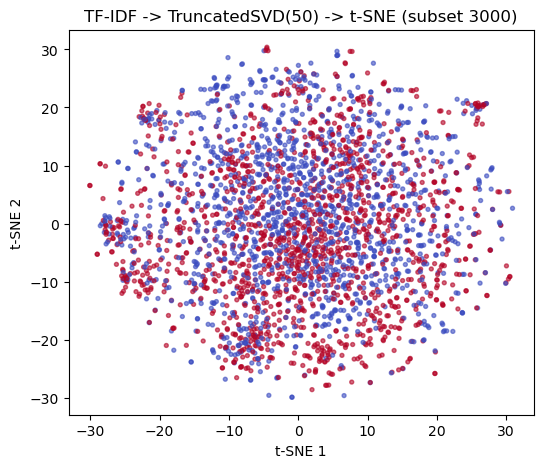

In [211]:
X50_tfidf, X_tsne_tfidf, idx_tfidf = reduce_and_tsne_plot(
    X_train_tfidf, y_train, 
    name="TF-IDF", n_components=50, tsne_subset=3000
)

**Notes**
* We cannot compare explained-variance percentages across the two reprensations as if they were the same scale--they reflect different geometries and preprocessing:
  * *Different input types*: TF-IDF is sparse & high-dimensional; GloVe doc vectors are dense & low-dimensional
  * *Centering*: PCA centers data (subtracts column means) before computing covariance. TruncatedSVD on sparse TF-IDF usually does not center (centering sparse matrices would make them dense and expensive). Centering changes the covariance structure and thus how variance is distributed
  * *Signal distribution*: TF-IDF gives large importance to many rare but discriminative tokens (e.g., specific words, n-grams); embeddings pack more signals into a smaller number of dimensions
* Both representations show *some* local structure, but neither gives a clean sentiment cluster in low-dimensional visualizations. This matches earlier model results: TF-IDF logistic does well because discriminative features are distributed / high-dimensional; embeddings need structure or weighting to expose those same signals

#### 7.3 Numeric Tests

In [69]:
def centroid_stats(X, y):
    pos = X[y==1]
    neg = X[y==0]
    cpos = pos.mean(axis=0); cneg = neg.mean(axis=0)
    inter = np.linalg.norm(cpos - cneg)
    intra_pos = np.mean(np.linalg.norm(pos - cpos, axis=1))
    intra_neg = np.mean(np.linalg.norm(neg - cneg, axis=1))
    return inter, (intra_pos + intra_neg) / 2

In [146]:
for name, X in [('GloVe-mean', X_train_mean),
                ('GloVe-weighted', X_train_weighted),
                ('TFIDF-SVD50', X50_tfidf)]:
    inter, intra = centroid_stats(X, y_train.values)
    print(name, 'inter:', inter, 'mean intra:', intra, 'ratio:', inter/(intra+1e-9))

GloVe-mean inter: 0.1478708839757885 mean intra: 0.5137983791958304 ratio: 0.28779943587877527
GloVe-weighted inter: 0.16988845550134876 mean intra: 1.0588119062415586 ratio: 0.16045196917358637
TFIDF-SVD50 inter: 0.07319111463146491 mean intra: 0.28464108422531187 ratio: 0.25713475120265716


* all ratios are < 1.0 -- very small; classes are not well-seperated in these reduced spaces

In [170]:
from sklearn.metrics.pairwise import cosine_similarity

cpos = X_train_mean[y_train==1].mean(axis=0).reshape(1,-1)
cneg = X_train_mean[y_train==0].mean(axis=0).reshape(1,-1)
sim_pos_to_pos = cosine_similarity(X_train_mean[y_train==1], cpos).ravel()
sim_pos_to_neg = cosine_similarity(X_train_mean[y_train==1], cneg).ravel()

print('pos mean sim to pos centroid:', sim_pos_to_pos.mean(), 'to neg centroid:', sim_pos_to_neg.mean())

pos mean sim to pos centroid: 0.9919239209914018 to neg centroid: 0.9912101799560387


* almost identical. Class centroids are nearly in the same direction

In [168]:
from sklearn.metrics import silhouette_score

print('silhouette (GloVe mean):', silhouette_score(X50p, y_train))

silhouette (GloVe mean): 0.021815543582597755


* essentially 0 -- clusters overlap heavily

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

def eval_logistic(X_train_rep, X_test_rep, y_train, y_test):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_rep, y_train)
    pred = clf.predict(X_test_rep)
    prob = clf.predict_proba(X_test_rep)[:,1]
    return accuracy_score(y_test, pred), roc_auc_score(y_test, prob)

In [164]:
print('TF-IDF logistic:', eval_logistic(X_train_tfidf.toarray(), X_test_tfidf.toarray(), y_train, y_test))
print('GloVe mean logistic:', eval_logistic(X_train_mean, X_test_mean, y_train, y_test))
print('GloVe weighted logistic:', eval_logistic(X_train_weighted, X_test_weighted, y_train, y_test))

TF-IDF logistic: (0.8905333333333333, 0.9565207111014429)
GloVe mean logistic: (0.7971333333333334, 0.8760315452566656)
GloVe weighted logistic: (0.7705333333333333, 0.8511271421557013)


We compared sparse lexical TF-IDF representations with dense pretrained GloVe document embeddings (mean and TF-IDF-weighted). TF-IDF combined with a linear classifier substantially outperformed GloVe-based representations (test AUC 0.956 vs 0.876 for mean-GloVe). Geometric diagnostics (centroid distances, silhouette score, and SVD/PCA into t-SNE visualizations) show that sentiment is not arranged as a compact geometric axis in the GloVe semantic space for this dataset; instead, discriminative cues are distributed across many sparse lexical features. 

TF-IDF with linear models remains a strong baseline for sentiment classification due to its ability to preserve sparse, lexical signals. Dense embeddings and hybrid approaches fail to outperform it because sentiment cues are not primarily semantic but lexical and compositional. Therefore, immediate next steps are to either (1) expand on further hybrids with more neural features (RNNs) for marginal improvements or (2) move to fine-tuning contextual transformers for a larger, but costlier, accuracy improvement.

## 8. Embedding Architectures III: RNNs

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
rnn_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=max_vocab,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),

    LSTM(128, name="lstm_repr"),

    # same classifier as before
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [52]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 289s 256ms/step - accuracy: 0.5033 - loss: 0.6939 - val_accuracy: 0.5052 - val_loss: 0.6930
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 227s 207ms/step - accuracy: 0.5085 - loss: 0.6911 - val_accuracy: 0.5112 - val_loss: 0.6857
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 237s 217ms/step - accuracy: 0.5257 - loss: 0.6755 - val_accuracy: 0.5266 - val_loss: 0.6668
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 240s 219ms/step - accuracy: 0.8419 - loss: 0.3448 - val_accuracy: 0.8959 - val_loss: 0.2742
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 243s 222ms/step - accuracy: 0.9319 - loss: 0.1847 - val_accuracy: 0.8991 - val_loss: 0.2516
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 240s 220ms/step - accuracy: 0.9590 - loss: 0.1171 - val_accuracy: 0.8983 - val_loss: 0.3054
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 237s 217ms/step - accuracy: 0.9796 - loss: 0.0690 - val_accuracy: 0.8923 - val_loss: 0.3877
Epoch 8/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 242s 221ms/step - ac

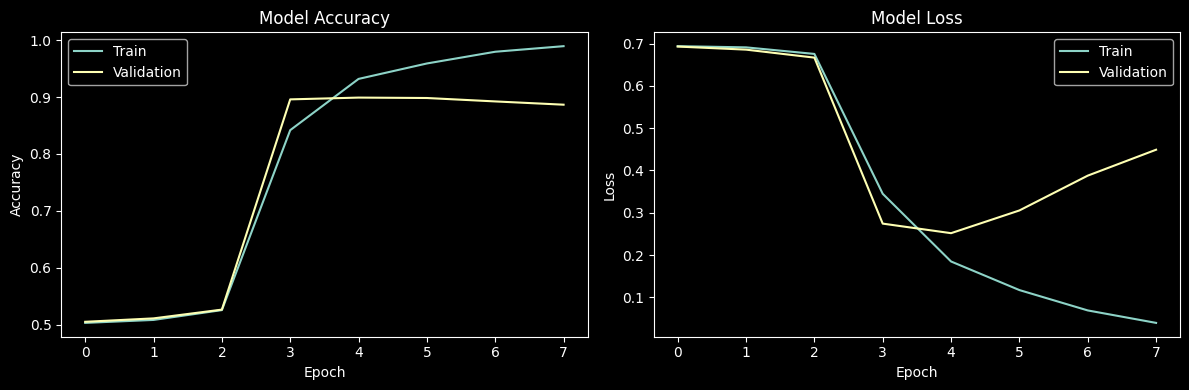

In [53]:
plot_training_history(history_rnn)

In [54]:
rnn_acc = history_rnn.history['val_accuracy'][-1]
rnn_acc

0.8866000175476074

In [57]:
print(rnn_model.inputs[0])

<KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_16>


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step
LSTM hidden state: PCA(50) explained variance (sum) = 0.998536


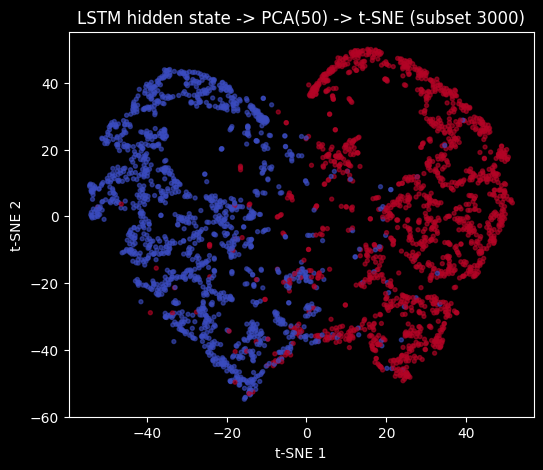

In [62]:
feature_model = Model(
    inputs=rnn_model.inputs[0],
    outputs=rnn_model.get_layer("lstm_repr").output
)

X_train_rnn = feature_model.predict(X_train_pad)
X_test_rnn  = feature_model.predict(X_test_pad)

X50_rnn, X_tsne_rnn, idx_rnn = reduce_and_tsne_plot(
    X_train_rnn, y_train,
    name="LSTM hidden state"
)

In [71]:
inter, intra = centroid_stats(X_train_rnn, y_train.values)
print('X_train_rnn', 'inter:', inter, 'mean intra:', intra, 'ratio:', inter/(intra+1e-9))

X_train_rnn inter: 2.325048 mean intra: 0.6865562 ratio: 3.3865368


In [65]:
from sklearn.metrics import silhouette_score

print('silhouette (RNN):', silhouette_score(X50_rnn, y_train))

silhouette (RNN): 0.5909541249275208


In [67]:
print('RNN logistic:', eval_logistic(X_train_rnn, X_test_rnn, y_train, y_test))

RNN logistic: (0.9002666666666667, 0.9623176545073642)


**Notes**

Instead of pooling, RNN instead leverages sequence memory before classifying, allowing it use order and local context rather than averaging everything together.

analogous to pooling/residual info